In [13]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import Client
import matplotlib.animation as animation
import numpy as np
import os
import xesmf as xe
import intake

In [14]:
client = Client(threads_per_worker=1)
#client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39935 instead
  warnings.warn(


## files
daily data for sots sub-region (depth, lat, long, time)
- `access-om3.mom6.region.3d.salt.z.1day.mean._2170.nc` 
- `access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc`
- `access-om3.mom6.region.3d.uo.z.1day.mean._2170.nc`
- `access-om3.mom6.region.3d.vo.z.1day.mean._2170.nc`
  
daily surface data for whole model (lat, long, time)
- `access-om3.mom6.2d.1day.mean._2170.nc`
  
daily surface flux data for whole model (lat, long, time)
- `access-om3.mom6.flux.2d.1day.mean._2170.nc`

In [15]:
# E.g. open dataset
base_dir = "/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output008/"
ds_surf = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.2d.1day.mean._2170.nc"))
ds_region = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"))

/jobfs/156253500.gadi-pbs/ipykernel_3066605/4235348879.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_surf = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.2d.1day.mean._2170.nc"))
/jobfs/156253500.gadi-pbs/ipykernel_3066605/4235348879.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_region = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"))


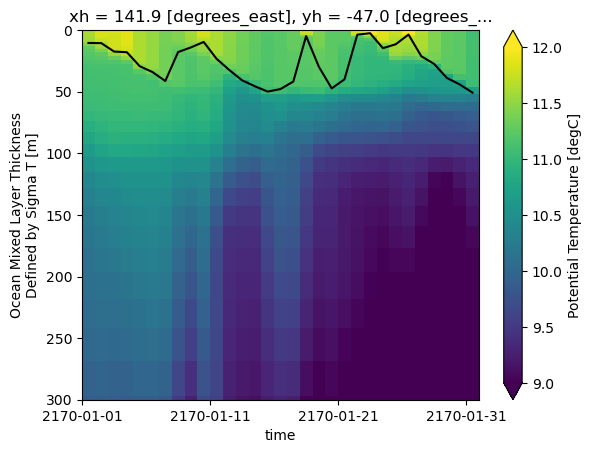

In [16]:
# example plot
ds_region.temp.isel(xh_sub02 = 25, yh_sub02 = 33).sel(z_l = slice (0, 900)).plot(x = "time", y = "z_l", ylim = [300, 0], vmin = 9, vmax = 12)
ds_surf.mlotst.sel(xh = 141.9, yh = -47, method = 'nearest').plot(color = 'k')